# New Rotation Experiment

A clean series of increasingly complex experiments exploring how rotation of Gaussian components manifests in the CT projection data.

---

## Experiment 1 — Single Fixed, Rotating Anisotropic Gaussian

We fix a single strongly anisotropic Gaussian at a static position and assign it a single angular velocity $\omega$.  
Because the mean $\boldsymbol{\mu}$ is constant, every change in the projection data is **purely due to rotation**.

**Geometry:** matches `configs/simulate.yaml` — one fan-beam source at $(-1,-1)$, 128 detectors on $x=4$, $y\in[-3,1]$.

**Outputs:**
- Side-by-side animation: rotating Gaussian ellipse (left) and its live projection profile (right).  
- Sinogram (`viridis`) showing the full $(t, y_r)$ intensity map.

In [1]:
import sys

_project_root = "/Users/danburrows/Projects/gmm-ct"
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

for _mod in list(sys.modules):
    if _mod == "gmm_ct" or _mod.startswith("gmm_ct."):
        del sys.modules[_mod]

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from IPython.display import Image

from gmm_ct.core.reconstruction import GMM_reco
from gmm_ct.utils.geometry import construct_receivers
import gmm_ct

print("gmm_ct loaded from:", gmm_ct.__file__)
device = torch.device("cpu")

gmm_ct loaded from: /Users/danburrows/Projects/gmm-ct/gmm_ct/__init__.py


## Geometry

Source and detector layout from `configs/simulate.yaml`:
- **Source:** $\mathbf{s} = (-1,\,-1)$
- **Detectors:** 128 elements on $x = 4$, spanning $y \in [-3, 1]$ (top-to-bottom internally, flipped for plotting)

In [2]:
d = 2

# Fan-beam source — matches simulate.yaml
sources = [torch.tensor([-1.0, -1.0], dtype=torch.float64, device=device)]

# 128 receivers at x = 4, y ∈ [-3, 1] — construct_receivers stores top-to-bottom
receivers = construct_receivers(device, (128, 4.0, -3.0, 1.0))
n_rcvrs   = len(receivers[0])

# Ascending y-coordinates for plotting (matches the flipped display convention)
y_rcvrs = np.linspace(-3.0, 1.0, n_rcvrs)

print(f"Source:    {sources[0].tolist()}")
print(f"Detectors: {n_rcvrs} receivers at x = 4.0,  y ∈ [{y_rcvrs[0]:.1f}, {y_rcvrs[-1]:.1f}]")

Source:    [-1.0, -1.0]
Detectors: 128 receivers at x = 4.0,  y ∈ [-3.0, 1.0]


## Gaussian Parameters

A single strongly anisotropic Gaussian:
- **Position** $x_0 = (1.5,\;-0.5)$ — centred in the fan beam, fully within the detector span.
- **Shape** $U_{\text{skew}}$: aspect ratio $\approx 6\!:\!1$, so rotation is clearly visible.
- **Angular velocity** $\omega = 3.0$ Hz (from the current search range $[2, 6]$ Hz in `simulate.yaml`).
- $\mathbf{v}_0 = \mathbf{a}_0 = \mathbf{0}$ — the mean is stationary throughout.

In [3]:
# ── Attenuation ─────────────────────────────────────────────────────────────
alpha = torch.tensor(20.0, dtype=torch.float64, device=device)

# ── Shape matrix (upper-triangular; precision = U^T U) ───────────────────────
# Large off-diagonal entry → strong elongation → rotation clearly visible
U_skew = torch.tensor([[8.0,  6.0],
                        [0.0, 20.0]], dtype=torch.float64, device=device)

# ── Position (fixed — no translational motion) ───────────────────────────────
x0 = torch.tensor([1.5, -0.5], dtype=torch.float64, device=device)
v0 = torch.zeros(d, dtype=torch.float64, device=device)
a0 = torch.zeros(d, dtype=torch.float64, device=device)

# ── Angular velocity ─────────────────────────────────────────────────────────
omega_val = 3.0   # Hz
omega     = torch.tensor([omega_val], dtype=torch.float64, device=device)

theta = {
    "alphas":  [alpha],
    "U_skews": [U_skew],
    "omegas":  [omega],
    "x0s":     [x0],
    "v0s":     [v0],
    "a0s":     [a0],
}

# Unrotated covariance (used for ellipse drawing)
P0     = (U_skew.T @ U_skew).detach().numpy()   # precision at t = 0
Sigma0 = np.linalg.inv(P0)
evals0 = np.linalg.eigvalsh(P0)

print(f"Position:          x0 = {x0.tolist()}")
print(f"Angular velocity:  ω  = {omega_val:+.1f} Hz  "
      f"→  {omega_val * 1.5:.2f} full revolutions over 1.5 s")
print(f"Precision anisotropy: {evals0[1]/evals0[0]:.1f}× "
      f"(max/min eigenvalue ratio)")

Position:          x0 = [1.5, -0.5]
Angular velocity:  ω  = +3.0 Hz  →  4.50 full revolutions over 1.5 s
Precision anisotropy: 7.6× (max/min eigenvalue ratio)


## Forward Model & Projections

We use 65 uniformly-spaced time steps over $T = 1.5$ s, matching `simulate.yaml`.

In [31]:
# ── Time grid from simulate.yaml ─────────────────────────────────────────────
n_projections = 165
duration      = 1.5   # seconds

t    = torch.linspace(0.0, duration, n_projections,
                      dtype=torch.float64, device=device)
t_np = t.detach().cpu().numpy()

# ── Forward model ────────────────────────────────────────────────────────────
model = GMM_reco(
    d=d, N=1,
    sources=sources,
    receivers=receivers,
    x0s=[x0], a0s=[a0],
    omega_min=2.0, omega_max=6.0,
    device=device,
)

with torch.no_grad():
    proj_list = model.generate_projections(t, theta)

proj    = model.process_projections(proj_list)   # (n_t, n_rcvrs)
proj_np = proj.detach().cpu().numpy()

# Flip detector axis so columns align with ascending y_rcvrs
proj_fl = proj_np[:, ::-1]

print(f"Projection shape:  {proj_fl.shape}   (time × detector)")
print(f"Intensity range:   [{proj_fl.min():.4f}, {proj_fl.max():.4f}]")

Projection shape:  (165, 128)   (time × detector)
Intensity range:   [0.0000, 4.6277]


## Animation — Rotating Gaussian & Live Projection

**Left panel:** 2-D spatial view. The Gaussian is shown as three nested ellipses at the $1\sigma$, $2\sigma$, and $3\sigma$ contours of the precision-normalised distribution. It rotates in place at $\omega = 3$ Hz.

**Right panel:** Fan-beam projection profile at each time step — intensity vs. detector height $y_r$.

In [11]:
x0_np  = x0.detach().numpy()
src_np = sources[0].detach().numpy()

# Receiver y-positions in descending order (as stored internally)
rcvr_ys_desc = np.array([r[1].item() for r in receivers[0]])

# ── Publication colour scheme ─────────────────────────────────────────────────
# Matches publication.py: rainbow cmap, K=1 → first colour (red end)
component_color = plt.cm.rainbow(np.linspace(0, 1, 1))[0]

# ── Helper ───────────────────────────────────────────────────────────────────
def rotated_ellipse_params(Sigma0, omega_hz, t_val, chi2=1.0):
    """Width, height (m), angle (deg) of the chi2 ellipse at time t_val."""
    theta_t = 2 * np.pi * omega_hz * t_val
    c, s = np.cos(theta_t), np.sin(theta_t)
    R = np.array([[c, -s], [s, c]])
    Sigma_r = R @ Sigma0 @ R.T
    evals, evecs = np.linalg.eigh(Sigma_r * chi2)
    # Publication convention: width = short axis, height = long axis,
    # angle = direction of short-axis eigenvector
    width  = 2 * np.sqrt(max(evals[0], 0))
    height = 2 * np.sqrt(max(evals[1], 0))
    angle  = np.degrees(np.arctan2(evecs[1, 0], evecs[0, 0]))
    return width, height, angle

# ── Figure setup ─────────────────────────────────────────────────────────────
fig, (ax_gmm, ax_proj) = plt.subplots(
    1, 2, figsize=(13, 5.5),
    gridspec_kw={"width_ratios": [1.15, 1]}
)
fig.subplots_adjust(wspace=0.32)

# ── Left: spatial domain ──────────────────────────────────────────────────────
ax_gmm.set_xlim(-1.8, 4.8)
ax_gmm.set_ylim(-3.4, 1.6)
ax_gmm.set_aspect("equal")
ax_gmm.set_xlabel("$x$ (m)", fontsize=11)
ax_gmm.set_ylabel("$y$ (m)", fontsize=11)
ax_gmm.set_title("Rotating Gaussian", fontsize=13, fontweight="bold")
ax_gmm.set_facecolor("#f8f9fa")
ax_gmm.grid(True, lw=0.4, alpha=0.3)

# Static geometry
ax_gmm.plot(*src_np, "s", color="firebrick", ms=10, zorder=10, label="Source")
ax_gmm.axvline(4.0, color="steelblue", lw=1.0, alpha=0.35, ls="--")
ax_gmm.plot([4.0] * n_rcvrs, rcvr_ys_desc, "|",
            color="steelblue", ms=6, mew=1.2, alpha=0.5, zorder=8,
            label="Detectors")

# Fan rays at t=0 (static, decorative)
for rcvr in receivers[0][::1]:   # every 16th receiver
    ry = rcvr[1].item()
    ax_gmm.plot([src_np[0], 4.0], [src_np[1], ry],
                color="gold", lw=0.5, alpha=0.65, zorder=1)

# Dynamic ellipse patches — publication style: [1σ, 2σ, 3σ] with rainbow colour,
# black edge, uniform alpha=0.8, linewidth decreasing outward, outermost on top
ELLIPSE_STYLE = [
    {"chi2": 1, "alpha": 0.8, "lw": 1.5, "zorder": 10},
    {"chi2": 4, "alpha": 0.8, "lw": 1.2, "zorder": 11},
    {"chi2": 9, "alpha": 0.8, "lw": 0.9, "zorder": 12},
]
ellipse_patches = []
for es in ELLIPSE_STYLE:
    w0, h0, a0_ = rotated_ellipse_params(Sigma0, omega_val, 0.0, chi2=es["chi2"])
    ep = mpatches.Ellipse(
        x0_np, width=w0, height=h0, angle=a0_,
        facecolor=component_color, edgecolor="black",
        alpha=es["alpha"], linewidth=es["lw"], zorder=es["zorder"]
    )
    ax_gmm.add_patch(ep)
    ellipse_patches.append((ep, es["chi2"]))

centroid_dot, = ax_gmm.plot(*x0_np, "o", color=component_color,
                             ms=8, markeredgewidth=2, zorder=20)
time_text = ax_gmm.text(
    0.03, 0.97, "",
    transform=ax_gmm.transAxes, va="top", fontsize=10,
    color="#222", fontfamily="monospace"
)
ax_gmm.legend(fontsize=9, loc="upper right")

# ── Right: projection profile ─────────────────────────────────────────────────
proj_max = proj_fl.max()
ax_proj.set_xlim(y_rcvrs[0], y_rcvrs[-1])
ax_proj.set_ylim(-0.02 * proj_max, proj_max * 1.14)
ax_proj.set_xlabel("Detector position $y_r$ (m)", fontsize=11)
ax_proj.set_ylabel("Projection intensity", fontsize=11)
ax_proj.set_title("Fan-beam Projection", fontsize=13, fontweight="bold")
ax_proj.grid(True, lw=0.4, alpha=0.3)
ax_proj.set_facecolor("#f8f9fa")

# proj_line,  = ax_proj.plot(y_rcvrs, proj_fl[0], color="#2E86AB", lw=2.2, zorder=5)
proj_line,  = ax_proj.plot(y_rcvrs, proj_fl[0], color='black', lw=2.2, zorder=5)
# proj_fill   = [ax_proj.fill_between(y_rcvrs, proj_fl[0], alpha=0.18, color="#2E86AB")]

fig.suptitle(
    rf"Single Rotating Gaussian  ($\omega = {omega_val:+.1f}$ Hz,  "
    rf"$\mathbf{{x}}_0 = {x0_np.tolist()}$)",
    fontsize=13, fontweight="bold", y=1.01,
)

# ── Update function ──────────────────────────────────────────────────────────
def update(frame):
    t_val = t_np[frame]
    # Update ellipses
    for ep, chi2 in ellipse_patches:
        w, h, ang = rotated_ellipse_params(Sigma0, omega_val, t_val, chi2=chi2)
        ep.set(width=w, height=h, angle=ang)
    # Rotation angle label
    theta_deg = (2 * np.pi * omega_val * t_val * 180 / np.pi) % 360
    time_text.set_text(f"t = {t_val:.3f} s\nθ = {theta_deg:.1f}°")
    # Projection profile
    proj_data = proj_fl[frame]
    proj_line.set_ydata(proj_data)
    # proj_fill[0].remove()
    # proj_fill[0] = ax_proj.fill_between(
        # y_rcvrs, proj_data, alpha=0.18, color="#2E86AB"
    # )
    return [ep for ep, _ in ellipse_patches] + [centroid_dot, time_text, proj_line]

anim = FuncAnimation(fig, update, frames=n_projections,
                     interval=80, blit=False)

print("Saving animation → exp1_rotating_gaussian.gif ...")
anim.save("exp1_rotating_gaussian.gif", writer="pillow", fps=12, dpi=120)
print("Saved.")
plt.close(fig)

Image(url="exp1_rotating_gaussian.gif")

Saving animation → exp1_rotating_gaussian.gif ...
Saved.


## Sinogram

The sinogram encodes the complete projection dataset as a single image: time $t$ on the horizontal axis and detector height $y_r$ on the vertical axis, with intensity rendered in `viridis`.

Because the Gaussian **centre is fixed**, the bright band stays at a constant $y_r$ over time. What changes is the **width and peak intensity** of each column, oscillating at a rate set by $\omega$ — the signature of rotation.

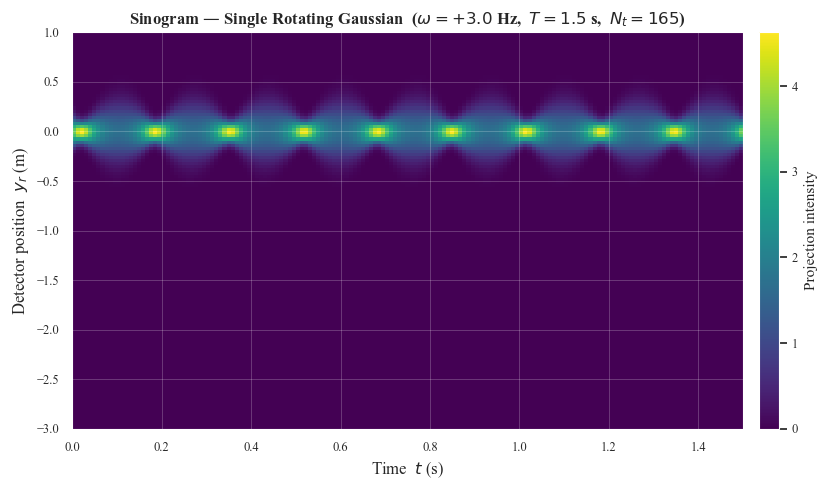

In [32]:
fig_sino, ax_sino = plt.subplots(figsize=(9, 5))

im_sino = ax_sino.imshow(
    proj_fl.T,
    aspect="auto",
    origin="lower",
    extent=[t_np[0], t_np[-1], y_rcvrs[0], y_rcvrs[-1]],
    cmap="viridis",
    interpolation="nearest",
)

fig_sino.colorbar(im_sino, ax=ax_sino,
                  label="Projection intensity", pad=0.02)

ax_sino.set_xlabel("Time  $t$ (s)", fontsize=12)
ax_sino.set_ylabel("Detector position  $y_r$ (m)", fontsize=12)
ax_sino.set_title(
    rf"Sinogram — Single Rotating Gaussian  "
    rf"($\omega = {omega_val:+.1f}$ Hz,  "
    rf"$T = {duration}$ s,  $N_t = {n_projections}$)",
    fontsize=12, fontweight="bold",
)

plt.tight_layout()
plt.show()

## Peak Projection vs. Time

The **peak** of each projection column — $\max_{r} p(t, y_r)$ — is a scalar time series that summarises how the total attenuation seen by the brightest ray evolves.  For a purely rotating Gaussian the peak oscillates at twice the rotation frequency (returning to its original value after every $180°$ rotation), giving a characteristic frequency of $2\omega$.


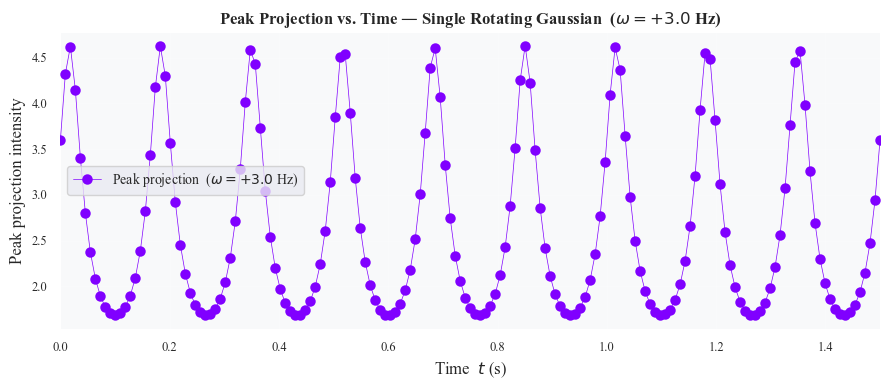

ω = 3.0 Hz  →  4.50 full rotations over 1.5 s
Expected peak period:  T_peak = 1/(2ω) = 0.1667 s
Peak intensity range:  [1.6845, 4.6277]


In [33]:
peak_vals = proj_fl.max(axis=1)   # (n_projections,) — max over detectors at each t

fig_peak, ax_peak = plt.subplots(figsize=(9, 4))

ax_peak.plot(t_np, peak_vals, color=component_color, lw=0.5, zorder=5, marker="o", markersize=6, markeredgewidth=1.5,
             label=rf"Peak projection  ($\omega = {omega_val:+.1f}$ Hz)")
# ax_peak.fill_between(t_np, peak_vals, alpha=0.15, color=component_color)

ax_peak.set_xlabel("Time  $t$ (s)", fontsize=12)
ax_peak.set_ylabel("Peak projection intensity", fontsize=12)
ax_peak.set_title(
    rf"Peak Projection vs. Time — Single Rotating Gaussian  ($\omega = {omega_val:+.1f}$ Hz)",
    fontsize=12, fontweight="bold",
)
ax_peak.set_xlim(t_np[0], t_np[-1])
ax_peak.grid(True, lw=0.4, alpha=0.4)
ax_peak.set_facecolor("#f8f9fa")
ax_peak.legend(fontsize=10)

plt.tight_layout()
plt.show()

n_cycles = omega_val * duration
print(f"ω = {omega_val} Hz  →  {n_cycles:.2f} full rotations over {duration} s")
print(f"Expected peak period:  T_peak = 1/(2ω) = {1/(2*omega_val):.4f} s")
print(f"Peak intensity range:  [{peak_vals.min():.4f}, {peak_vals.max():.4f}]")


---

## Experiment 2 — Three Rotating Gaussians in Projectile Motion

Three anisotropic Gaussians, all starting at $\mathbf{x}_0 = (0, 0)$ with non-negative horizontal velocity and gravitational acceleration $\mathbf{a} = (0, -9.81)$ m/s².  Each component has a distinct shape, speed and angular velocity, so their trajectories and rotational signatures are clearly separable in the sinogram.


In [34]:

# ── Common parameters ────────────────────────────────────────────────────────
colors_exp2 = plt.cm.rainbow(np.linspace(0, 1, 3))  # K=3 publication colours

x0_all    = torch.tensor([0.0,   0.0], dtype=torch.float64, device=device)
a_gravity = torch.tensor([0.0, -9.81], dtype=torch.float64, device=device)

# ── Three Gaussians: distinct shape, velocity, omega ────────────────────────
gauss_defs = [
    dict(
        label  = r"$G_1$:  $\omega=+2$ Hz",
        v0     = torch.tensor([1.30, 2.0],  dtype=torch.float64, device=device),
        omega  = torch.tensor([  2.0],      dtype=torch.float64, device=device),
        alpha  = torch.tensor(  20.0,       dtype=torch.float64, device=device),
        U_skew = torch.tensor([[ 8.0,  6.0],
                                [ 0.0, 20.0]], dtype=torch.float64, device=device),
    ),
    dict(
        label  = r"$G_2$:  $\omega=-3.5$ Hz",
        v0     = torch.tensor([2.85, 0.5],  dtype=torch.float64, device=device),
        omega  = torch.tensor([ -3.5],      dtype=torch.float64, device=device),
        alpha  = torch.tensor(  15.0,       dtype=torch.float64, device=device),
        U_skew = torch.tensor([[ 5.0,  8.0],
                                [ 0.0, 12.0]], dtype=torch.float64, device=device),
    ),
    dict(
        label  = r"$G_3$:  $\omega=+5$ Hz",
        v0     = torch.tensor([3.50, 3.0],  dtype=torch.float64, device=device),
        omega  = torch.tensor([  5.0],      dtype=torch.float64, device=device),
        alpha  = torch.tensor(  18.0,       dtype=torch.float64, device=device),
        U_skew = torch.tensor([[12.0, -4.0],
                                [ 0.0,  6.0]], dtype=torch.float64, device=device),
    ),
]

theta_exp2 = {
    "alphas":  [g["alpha"]        for g in gauss_defs],
    "U_skews": [g["U_skew"]       for g in gauss_defs],
    "omegas":  [g["omega"]        for g in gauss_defs],
    "x0s":     [x0_all.clone()    for _ in gauss_defs],
    "v0s":     [g["v0"]           for g in gauss_defs],
    "a0s":     [a_gravity.clone() for _ in gauss_defs],
}

# ── Forward model (N=3) ──────────────────────────────────────────────────────
model_exp2 = GMM_reco(
    d=d, N=3,
    sources=sources, receivers=receivers,
    x0s=[x0_all.clone()    for _ in gauss_defs],
    a0s=[a_gravity.clone() for _ in gauss_defs],
    omega_min=2.0, omega_max=6.0,
    device=device,
)

with torch.no_grad():
    proj_list2 = model_exp2.generate_projections(t, theta_exp2)

proj2    = model_exp2.process_projections(proj_list2)
proj_np2 = proj2.detach().cpu().numpy()
proj_fl2 = proj_np2[:, ::-1]   # flip → ascending y_rcvrs

print(f"Projection shape:  {proj_fl2.shape}   (time × detector)")
print(f"Intensity range:   [{proj_fl2.min():.4f}, {proj_fl2.max():.4f}]")
print()
for i, g in enumerate(gauss_defs):
    v  = g["v0"].numpy()
    om = g["omega"].item()
    xT = v[0] * duration
    yT = v[1] * duration + 0.5 * (-9.81) * duration**2
    print(f"G{i+1}: v0=({v[0]:.2f}, {v[1]:.2f}),  ω={om:+.1f} Hz"
          f"  →  final pos ({xT:.2f}, {yT:.2f})")


Projection shape:  (165, 128)   (time × detector)
Intensity range:   [0.0000, 6.8421]

G1: v0=(1.30, 2.00),  ω=+2.0 Hz  →  final pos (1.95, -8.04)
G2: v0=(2.85, 0.50),  ω=-3.5 Hz  →  final pos (4.28, -10.29)
G3: v0=(3.50, 3.00),  ω=+5.0 Hz  →  final pos (5.25, -6.54)


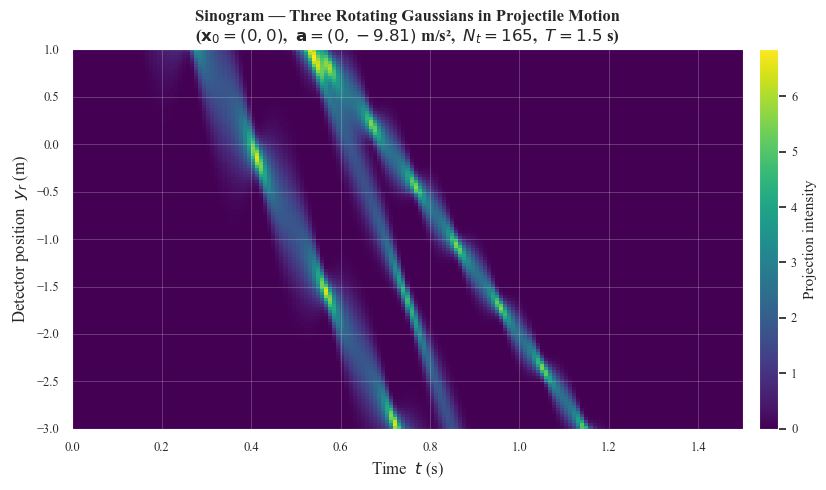

In [35]:
fig2, ax2 = plt.subplots(figsize=(9, 5))

im2 = ax2.imshow(
    proj_fl2.T,
    aspect="auto",
    origin="lower",
    extent=[t_np[0], t_np[-1], y_rcvrs[0], y_rcvrs[-1]],
    cmap="viridis",
    interpolation="nearest",
)

fig2.colorbar(im2, ax=ax2, label="Projection intensity", pad=0.02)

ax2.set_xlabel("Time  $t$ (s)", fontsize=12)
ax2.set_ylabel("Detector position  $y_r$ (m)", fontsize=12)
ax2.set_title(
    r"Sinogram — Three Rotating Gaussians in Projectile Motion"
    "\n"
    r"($\mathbf{x}_0 = (0,0)$,  $\mathbf{a} = (0,-9.81)$ m/s²,"
    rf"  $N_t = {n_projections}$,  $T = {duration}$ s)",
    fontsize=12, fontweight="bold",
)

plt.tight_layout()
plt.show()


---

## Direct Projection Plots — Individual Components and Mixture

Each panel shows a snapshot of the fan-beam projection at a selected time $t$.  
Individual Gaussian projections are **colour-coded** (matching their component colours); the **Gaussian mixture** projection (their sum) is plotted in **black**.

Four equally-spaced snapshots are shown across the duration $T = 1.5$ s.


In [36]:
# ── Per-component projections ────────────────────────────────────────────────
# Run the forward model separately for each Gaussian so we can plot individual
# contributions alongside the mixture.

indiv_proj_fl = []   # list of 3 arrays, each shape (n_projections, n_rcvrs)

for k, g in enumerate(gauss_defs):
    theta_k = {
        "alphas":  [g["alpha"]],
        "U_skews": [g["U_skew"]],
        "omegas":  [g["omega"]],
        "x0s":     [x0_all.clone()],
        "v0s":     [g["v0"]],
        "a0s":     [a_gravity.clone()],
    }
    m_k = GMM_reco(
        d=d, N=1,
        sources=sources, receivers=receivers,
        x0s=[x0_all.clone()], a0s=[a_gravity.clone()],
        omega_min=2.0, omega_max=6.0,
        device=device,
    )
    with torch.no_grad():
        pl_k = m_k.generate_projections(t, theta_k)
    p_k = m_k.process_projections(pl_k).detach().cpu().numpy()
    indiv_proj_fl.append(p_k[:, ::-1])   # flip → ascending y_rcvrs
    print(f"G{k+1} projection range: [{p_k.min():.4f}, {p_k.max():.4f}]")

# Quick sanity check: sum of individuals should equal the mixture
residual = np.abs(sum(indiv_proj_fl) - proj_fl2).max()
print(f"\nMax |sum(individuals) − mixture|: {residual:.2e}  (should be ~0)")


G1 projection range: [0.0000, 4.6467]
G2 projection range: [0.0000, 6.5139]
G3 projection range: [0.0000, 5.6305]

Max |sum(individuals) − mixture|: 0.00e+00  (should be ~0)


/var/folders/c9/3ysm_yh562vg5nz04zw5x80w0000gn/T/ipykernel_71852/3080296010.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


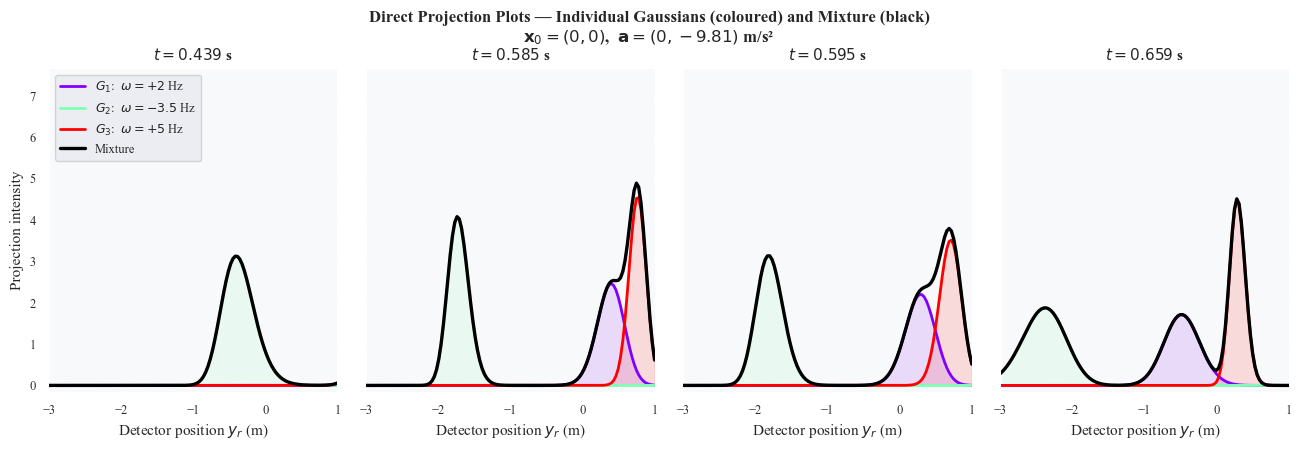

In [68]:
# ── Four equally-spaced time snapshots ──────────────────────────────────────
snap_indices = np.round(np.linspace(0, n_projections - 1, 4)).astype(int)
# snap_indices = [48, 64, 72, 82]   # hardcoded for n_projections=165
snap_indices = [48, 64, 68, 72]   # hardcoded for n_projections=165
snap_indices = [48, 64, 65, 72]   # hardcoded for n_projections=165

fig_dp, axes_dp = plt.subplots(
    1, 4, figsize=(16, 4.2), sharey=True,
    gridspec_kw={"wspace": 0.10},
)

y_max_global = proj_fl2.max() * 1.12

for col, idx in enumerate(snap_indices):
    ax = axes_dp[col]
    t_val = t_np[idx]

    # Individual Gaussian projections
    for k, (p_k, g) in enumerate(zip(indiv_proj_fl, gauss_defs)):
        ax.plot(y_rcvrs, p_k[idx], color=colors_exp2[k], lw=2.0,
                label=g["label"] if col == 0 else None, zorder=4)
        ax.fill_between(y_rcvrs, p_k[idx], alpha=0.12, color=colors_exp2[k])

    # Gaussian mixture
    ax.plot(y_rcvrs, proj_fl2[idx], color="black", lw=2.4, ls="-",
            label="Mixture" if col == 0 else None, zorder=5)

    ax.set_xlim(y_rcvrs[0], y_rcvrs[-1])
    ax.set_ylim(-0.02 * y_max_global, y_max_global)
    ax.set_xlabel("Detector position $y_r$ (m)", fontsize=11)
    ax.set_title(f"$t = {t_val:.3f}$ s", fontsize=11, fontweight="bold")
    ax.grid(True, lw=0.4, alpha=0.4)
    ax.set_facecolor("#f8f9fa")

axes_dp[0].set_ylabel("Projection intensity", fontsize=11)
axes_dp[0].legend(fontsize=9, loc="upper left")

fig_dp.suptitle(
    "Direct Projection Plots — Individual Gaussians (coloured) and Mixture (black)\n"
    r"$\mathbf{x}_0 = (0,0)$,  $\mathbf{a} = (0,-9.81)$ m/s²",
    fontsize=12, fontweight="bold", y=1.02,
)

plt.tight_layout()
# plt.show()


---

## Projection Modes — Mixture and Individual Gaussians

A **mode** of the projection at time $t$ is a local maximum of $p(t, \cdot)$ as a function of detector height $y_r$.

**Left 2×2 panels:** four time snapshots.  Individual Gaussian projections are colour-coded; the mixture is black.  Vertical dashed lines drop from each mixture mode to the baseline, with a coloured dot marking the mode position.

**Right panel:** modes plotted as a function of time across the full duration.  Mixture modes are shown as filled circles (●); individual component modes as crosses (×).


Time steps with ≥1 mixture mode: 94 / 165
(Gaps are time steps where all Gaussians have fallen below y = -3.0 m)


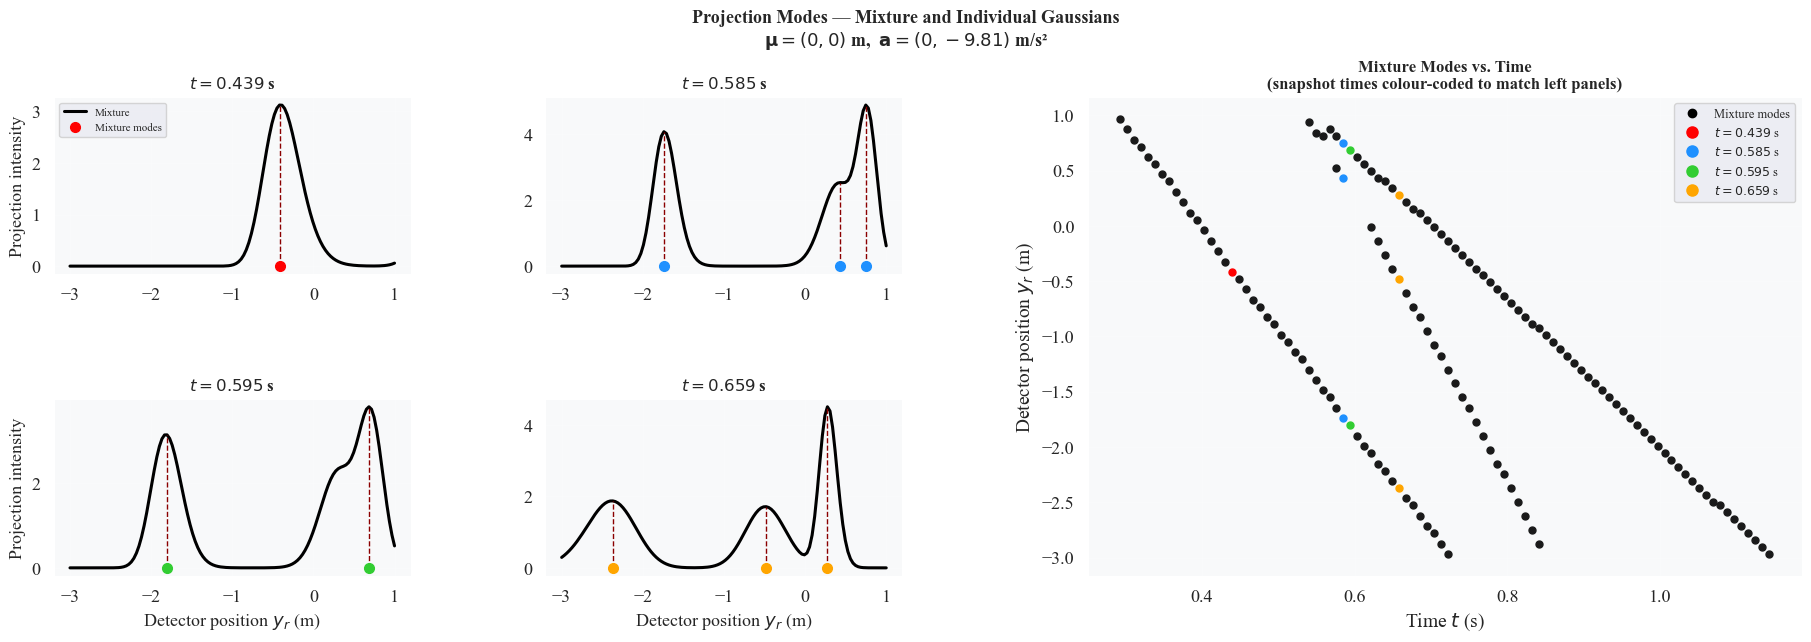

In [71]:
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from scipy.signal import find_peaks

receiver_heights = y_rcvrs   # ascending y, matches flipped proj arrays

def detect_peaks_and_modes(proj_rows, recv_heights, min_height_frac=0.01):
    """
    Return (peaks_list, modes_list) for a list of 1-D projection arrays.

    Uses scipy.signal.find_peaks so that:
      - boundary samples (index 0 and -1) are included as candidates.
      - peaks below `min_height_frac * global_max` are ignored (noise floor).
    """
    global_max = max(g.max() for g in proj_rows if len(g) > 0)
    min_height = min_height_frac * global_max

    peaks_list, modes_list = [], []
    for g in proj_rows:
        idx, _ = find_peaks(g, height=min_height)
        peaks_list.append([g[i]            for i in idx])
        modes_list.append([recv_heights[i] for i in idx])
    return peaks_list, modes_list

# ── Snapshot indices & panel accent colours ──────────────────────────────────
time_sample_inds = snap_indices          # [48, 64, 72, 82]
panel_colors     = ['red', 'dodgerblue', 'limegreen', 'orange']

# Mode detection on the 4 mixture snapshots
snap_mix         = [proj_fl2[i] for i in time_sample_inds]
peaks_mix, modes_mix = detect_peaks_and_modes(snap_mix, receiver_heights)

# ── Full-time mode detection: mixture and individual components ───────────────
all_mix_rows = [proj_fl2[n]    for n in range(n_projections)]
_, all_modes_mix = detect_peaks_and_modes(all_mix_rows, receiver_heights)

all_modes_indiv = []
for k in range(3):
    rows_k = [indiv_proj_fl[k][n] for n in range(n_projections)]
    _, modes_k = detect_peaks_and_modes(rows_k, receiver_heights)
    all_modes_indiv.append(modes_k)

# ── Figure layout ─────────────────────────────────────────────────────────────
fig_m = plt.figure(figsize=(18, 10), layout='constrained')
gs    = GridSpec(4, 4, figure=fig_m, hspace=0.15, wspace=0.25)

ax0 = fig_m.add_subplot(gs[0, 0])
ax1 = fig_m.add_subplot(gs[0, 1])
ax2 = fig_m.add_subplot(gs[1, 0])
ax3 = fig_m.add_subplot(gs[1, 1])
ax4 = fig_m.add_subplot(gs[0:2, 2:])
axs = [ax0, ax1, ax2, ax3]

# ── Small panels ──────────────────────────────────────────────────────────────
for col, (ax, idx) in enumerate(zip(axs, time_sample_inds)):
    t_val = t_np[idx]

    # Mixture
    ax.plot(receiver_heights, proj_fl2[idx], color='black', lw=2.2, zorder=5,
            label='Mixture' if col == 0 else None)

    # Mixture mode markers — coloured dots matching the right panel
    modes, peaks = modes_mix[col], peaks_mix[col]
    ax.vlines(modes, 0, peaks, color='darkred', linestyle='--', lw=1.0, zorder=6)
    ax.plot(modes, np.zeros(len(modes)), marker='o', lw=0,
            color=panel_colors[col], ms=7, zorder=7,
            label='Mixture modes' if col == 0 else None)

    ax.set_title(f"$t = {t_val:.3f}$ s", fontsize=12, fontweight='bold')
    ax.set_facecolor('#f8f9fa')
    ax.grid(True, lw=0.4, alpha=0.4)
    if col >= 2:
        ax.set_xlabel('Detector position $y_r$ (m)', fontsize=13)
    if col % 2 == 0:
        ax.set_ylabel('Projection intensity', fontsize=13)
    if col == 0:
        ax.legend(fontsize=8, loc='upper left')
    ax.tick_params(axis='both', which='major', labelsize=13)
    
def detect_peaks_and_modes(sampled_projs):
    N_plot_samples = len(sampled_projs)
    peaks_list = [[] for _ in range(N_plot_samples)]
    modes_list = [[] for _ in range(N_plot_samples)]
    for n_g, g in enumerate(sampled_projs):
        for j in range(1, len(g) - 1):
            gj_minus_1 = g[j - 1]
            gj = g[j]
            gj_plus_1 = g[j + 1]

            # Test for peak
            if gj_minus_1 < gj and gj > gj_plus_1:
                peaks_list[n_g].append(gj)
                modes_list[n_g].append(receiver_heights[j])
    
    return peaks_list, modes_list
    
colors = ['red', 'dodgerblue', 'limegreen', 'orange', 'salmon']
color_counter = 0
data_peaks, data_modes = detect_peaks_and_modes(proj_fl2)
for n_t, t_k in enumerate(t):
    n_modes = len(data_modes[n_t])
    if n_t not in time_sample_inds:
        ax4.plot(t_k * torch.ones(n_modes), np.array(data_modes[n_t]), marker='o', lw=0, color='k', ms=5)
    else:
        ax4.plot(t_k * torch.ones(n_modes), np.array(data_modes[n_t]), marker='o', lw=0, color=colors[color_counter], ms=5)
        color_counter += 1

ax4.set_xlabel('Time $t$ (s)', fontsize=14)
ax4.set_ylabel('Detector position $y_r$ (m)', fontsize=14)
ax4.set_title('Mixture Modes vs. Time\n(snapshot times colour-coded to match left panels)',
              fontsize=12, fontweight='bold')
ax4.grid(True, lw=0.4, alpha=0.4)
ax4.set_facecolor('#f8f9fa')
ax4.tick_params(axis='both', which='major', labelsize=13)

legend_handles = [Line2D([0], [0], marker='o', color='black', lw=0, ms=6, label='Mixture modes')] + [
    Line2D([0], [0], marker='o', color=panel_colors[i], lw=0, ms=8,
           label=f"$t = {t_np[time_sample_inds[i]]:.3f}$ s")
    for i in range(len(time_sample_inds))
]
ax4.legend(handles=legend_handles, fontsize=9)

# Diagnostic: report how many time steps have at least one mode
n_with_modes = sum(1 for m in all_modes_mix if m)
print(f"Time steps with ≥1 mixture mode: {n_with_modes} / {n_projections}")
print(f"(Gaps are time steps where all Gaussians have fallen below y = {receiver_heights[0]:.1f} m)")

fig_m.suptitle(
    'Projection Modes — Mixture and Individual Gaussians\n'
    r'$\mathbf{\mu} = (0,0)$ m,  $\mathbf{a} = (0,-9.81)$ m/s²',
    fontsize=13, fontweight='bold',
)
plt.show()
